In [40]:
import pandas as pd
import numpy as np
# 读取CSV文件
df_apple = pd.read_csv("688981_posts_data.csv")


In [42]:
# 所有时间都是 2025 年的
df_apple['Date'] = "2025-" + df_apple['Date']
df_apple['Date'] = pd.to_datetime(df_apple['Date']).dt.date 
# df_apple['Date'] = pd.to_datetime(df_apple['Date'], format="%Y-%m-%d %H:%M")
df_apple.head()

,read_count,title,Date
0,5951,科创板公司攻坚“硬卡替” 带领集成电路等产业向高质量攀登,2025-04-13
1,1,，谁都不跟。就是压制,2025-04-14
2,320,我一直有一种预感，特朗普的半导体关税有可能是触发中芯国际大牛行情的关键因素,2025-04-14
3,43,大盘行情那么好，我手拿五个绿的，的，这么玩吗，飞要让老子销户,2025-04-14
4,19,美国关税反复，对中芯应该利好，为什么跌呢？,2025-04-14


In [44]:
import pandas as pd
import re



# 简单清洗文本（去除特殊符号、空格等）
def clean_text(text):
    text = re.sub(r'[^\w\s]', '', str(text))  # 去除非字母数字字符
    text = text.strip()  # 去除首尾空格
    return text

df_apple["title"] = df_apple["title"].apply(clean_text)

print(df_apple.head())  # 检查清洗后的数据

   read_count                                 title        Date
0        5951            科创板公司攻坚硬卡替 带领集成电路等产业向高质量攀登  2025-04-13
1           1                              谁都不跟就是压制  2025-04-14
2         320  我一直有一种预感特朗普的半导体关税有可能是触发中芯国际大牛行情的关键因素  2025-04-14
3          43            大盘行情那么好我手拿五个绿的的这么玩吗飞要让老子销户  2025-04-14
4          19                    美国关税反复对中芯应该利好为什么跌呢  2025-04-14


In [46]:
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

# 使用专为中文设计的情感分析模型
model_name = "uer/roberta-base-finetuned-jd-binary-chinese"  # 京东评论情感分析模型
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# 创建中文情感分析pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# 分析中文文本
results_apple = []
for tweet in df_apple["title"]:
    try:
        sentiment = sentiment_pipeline(tweet)[0]
        # 转换标签格式以匹配后续处理代码
        # 这个模型的标签是 "positive" 和 "negative"
        results_apple.append((tweet, [sentiment]))
    except Exception as e:
        # 处理可能的错误，比如文本太长或格式问题
        print(f"处理文本时出错: {tweet}")
        print(e)
        results_apple.append((tweet, [{"label": "neutral", "score": 0.5}]))

results_apple

Device set to use mps:0


[('科创板公司攻坚硬卡替 带领集成电路等产业向高质量攀登',
  [{'label': 'positive (stars 4 and 5)', 'score': 0.8365708589553833}]),
 ('谁都不跟就是压制',
  [{'label': 'negative (stars 1, 2 and 3)', 'score': 0.937227725982666}]),
 ('我一直有一种预感特朗普的半导体关税有可能是触发中芯国际大牛行情的关键因素',
  [{'label': 'positive (stars 4 and 5)', 'score': 0.9490432143211365}]),
 ('大盘行情那么好我手拿五个绿的的这么玩吗飞要让老子销户',
  [{'label': 'negative (stars 1, 2 and 3)', 'score': 0.5368716716766357}]),
 ('美国关税反复对中芯应该利好为什么跌呢',
  [{'label': 'negative (stars 1, 2 and 3)', 'score': 0.52066570520401}]),
 ('整个A股就一个板块是绿的',
  [{'label': 'negative (stars 1, 2 and 3)', 'score': 0.7985963821411133}]),
 ('要做好突破千元的思想准备',
  [{'label': 'positive (stars 4 and 5)', 'score': 0.9371117353439331}]),
 ('这股专坑国产代替情怀大怨种',
  [{'label': 'negative (stars 1, 2 and 3)', 'score': 0.9064918756484985}]),
 ('还不抢只能说脑壳里少了东西的',
  [{'label': 'positive (stars 4 and 5)', 'score': 0.7754605412483215}]),
 ('中心国际弱的不行了',
  [{'label': 'negative (stars 1, 2 and 3)', 'score': 0.8402296900749207}]),
 ('明天要不就收绿要不就高开低走一定不能

In [5]:
final_scores = []
for result in results_apple:
    sentiment = result[1][0]
    label = sentiment["label"]
    score = sentiment["score"]

    # LABEL_0: Negative
    # LABEL_1: Neutral
    # LABEL_2: Positive
    if label == "positive (stars 4 and 5)":
        final_scores.append(score)
    elif label == "negative (stars 1, 2 and 3)":
        final_scores.append(-1*score)
    else:
        final_scores.append(0)
df_apple.loc[:,"score"] = final_scores
df_apple

,read_count,title,Date,score
0,5951,科创板公司攻坚硬卡替 带领集成电路等产业向高质量攀登,2025-04-13,0.836571
1,1,谁都不跟就是压制,2025-04-14,-0.937228
2,320,我一直有一种预感特朗普的半导体关税有可能是触发中芯国际大牛行情的关键因素,2025-04-14,0.949043
3,43,大盘行情那么好我手拿五个绿的的这么玩吗飞要让老子销户,2025-04-14,-0.536872
4,19,美国关税反复对中芯应该利好为什么跌呢,2025-04-14,-0.520666
...,...,...,...,...
496,47,国产替代中国自主,2025-04-10,0.631577
497,48,今天要大涨了,2025-04-10,0.644732
498,118,加关税半导体设备赢一次海外建厂苹果设备铲子股再赢一次应该是赢两次吧,2025-04-10,0.790662
499,60,这货不应该跌得这么惨没骨气,2025-04-10,-0.915901


In [47]:
import pandas as pd

# 假设df_apple是您已有的DataFrame（如图片所示）
# 包含列：read_count, title, Date, score（初始全为0.0）

# 2. 将分数赋值给DataFrame（修正图片中的拼写错误）
df_apple.loc[:, "score"] = final_scores  # 原图片代码有拼写错误(df APPLE,locL::"score"])

# 3. 计算每日加权平均分（按阅读量加权）
# 首先确保日期格式正确
df_apple["Date"] = pd.to_datetime(df_apple["Date"]).dt.date

# 计算加权分数
df_apple["weighted_score"] = df_apple["score"] * df_apple["read_count"]

# 按日期分组计算加权平均
daily_avg = df_apple.groupby("Date").apply(
    lambda x: x["weighted_score"].sum() / x["read_count"].sum() if x["read_count"].sum() > 0 else 0
).reset_index(name="score")

# 4. 输出结果
print("每日加权平均分：")
print(daily_avg)

# 可选：保存结果
daily_avg.to_csv("daily_weighted_scores.csv", index=False)

每日加权平均分：
          Date     score
0   2025-02-09  0.731207
1   2025-02-14  0.714727
2   2025-02-18  0.702431
3   2025-02-19  0.760273
4   2025-03-12  0.797821
5   2025-03-13  0.657588
6   2025-03-24  0.878776
7   2025-03-27  0.791734
8   2025-03-28  0.901964
9   2025-03-31  0.667927
10  2025-04-02 -0.824706
11  2025-04-03  0.200030
12  2025-04-06  0.661034
13  2025-04-07  0.571670
14  2025-04-08  0.246333
15  2025-04-09  0.805895
16  2025-04-10  0.312052
17  2025-04-11  0.567828
18  2025-04-12 -0.014913
19  2025-04-13  0.551582
20  2025-04-14  0.666444


/var/folders/h8/v5cmxjw939l6xq5v2v4hxgrm0000gn/T/ipykernel_18117/707320577.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_avg = df_apple.groupby("Date").apply(


In [50]:
df_apple.describe()

,read_count,score,weighted_score
count,501.000000,501.000000,501.000000
mean,688.746507,0.092574,392.013778
std,2975.364898,0.771925,2163.413838
min,1.000000,-0.983391,-1354.278545
25%,75.000000,-0.751535,-68.209912
50%,139.000000,0.567887,43.164939
75%,274.000000,0.778177,131.724796
max,36887.000000,0.988254,26537.947108


In [52]:
# pip install akshare --upgrade

In [54]:
import akshare as ak

# 使用 akshare 获取中芯国际 688981 历史数据
# 注意：日期范围不能是未来时间（2025年），改为2024年
data = ak.stock_zh_a_hist(symbol="688981", period="daily", start_date="20250201", end_date="20250415")

# 数据处理
data = data.rename(columns={
    "日期": "Date",
    "收盘": "close",
})[["Date", "close"]]  # 只保留这两列

print(data.head())


         Date   close
0  2025-02-05  101.37
1  2025-02-06  104.43
2  2025-02-07  102.53
3  2025-02-10  103.85
4  2025-02-11  100.86


Epoch 1/100


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 - 1s - 43ms/step - loss: 0.1759
Epoch 2/100
15/15 - 0s - 2ms/step - loss: 0.0197
Epoch 3/100
15/15 - 0s - 2ms/step - loss: 0.0145
Epoch 4/100
15/15 - 0s - 2ms/step - loss: 0.0089
Epoch 5/100
15/15 - 0s - 2ms/step - loss: 0.0065
Epoch 6/100
15/15 - 0s - 2ms/step - loss: 0.0054
Epoch 7/100
15/15 - 0s - 2ms/step - loss: 0.0049
Epoch 8/100
15/15 - 0s - 2ms/step - loss: 0.0048
Epoch 9/100
15/15 - 0s - 2ms/step - loss: 0.0048
Epoch 10/100
15/15 - 0s - 2ms/step - loss: 0.0047
Epoch 11/100
15/15 - 0s - 2ms/step - loss: 0.0046
Epoch 12/100
15/15 - 0s - 2ms/step - loss: 0.0046
Epoch 13/100
15/15 - 0s - 2ms/step - loss: 0.0046
Epoch 14/100
15/15 - 0s - 2ms/step - loss: 0.0045
Epoch 15/100
15/15 - 0s - 2ms/step - loss: 0.0045
Epoch 16/100
15/15 - 0s - 2ms/step - loss: 0.0045
Epoch 17/100
15/15 - 0s - 2ms/step - loss: 0.0044
Epoch 18/100
15/15 - 0s - 2ms/step - loss: 0.0044
Epoch 19/100
15/15 - 0s - 2ms/step - loss: 0.0044
Epoch 20/100
15/15 - 0s - 2ms/step - loss: 0.0044
Epoch 21/100
15/15 -

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31080 (\N{CJK UNIFIED IDEOGRAPH-7968}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaV

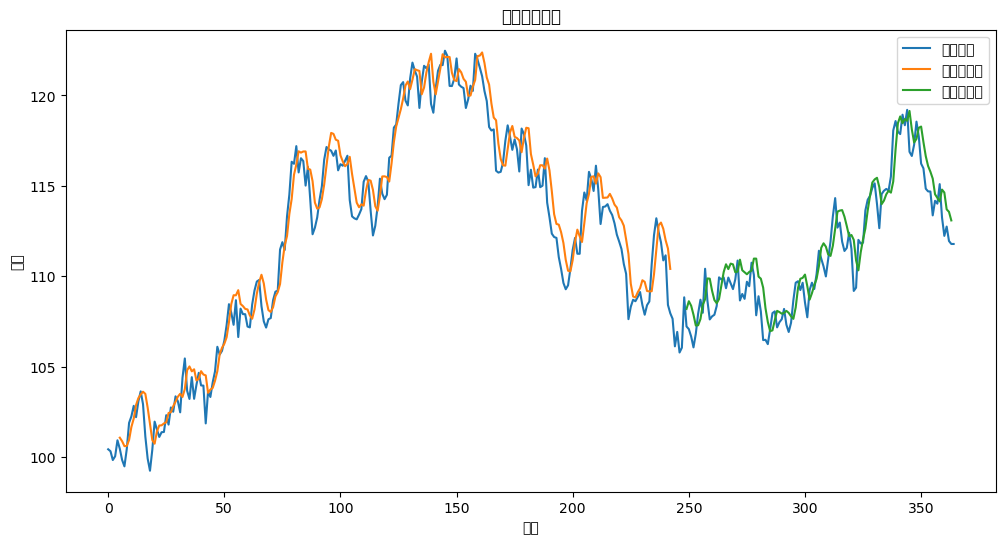

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# 将值数组转换为数据集矩阵
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        dataX.append(dataset[i:(i+look_back), :])
        dataY.append(dataset[i + look_back, 0])  # 我们只预测收盘价
    return np.array(dataX), np.array(dataY)

# 固定随机种子以便复现
tf.random.set_seed(7)

# 假设我们有两个DataFrame: daily_avg(Date, score)和data(Date, close)
# 这里我们模拟创建这两个数据集
# 在实际应用中，您需要从文件或数据库加载真实数据

# 创建模拟数据
dates = pd.date_range(start='2020-01-01', periods=365, freq='D')
np.random.seed(42)
scores = np.random.uniform(-1, 1, size=365)
closes = 100 + np.cumsum(np.random.normal(0, 1, 365))

daily_avg = pd.DataFrame({'Date': dates, 'score': scores})
data = pd.DataFrame({'Date': dates, 'close': closes})

# 合并两个数据集
merged_data = pd.merge(daily_avg, data, on='Date')
merged_data.set_index('Date', inplace=True)

# 选择特征 - 收盘价和分数
dataset = merged_data[['close', 'score']].values.astype('float32')

# 规范化数据集
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset)

# 分割为训练集和测试集
train_size = int(len(dataset_scaled) * 0.67)
test_size = len(dataset_scaled) - train_size
train, test = dataset_scaled[0:train_size,:], dataset_scaled[train_size:len(dataset_scaled),:]

# 重新整形为 X=t 和 Y=t+1
look_back = 5  # 使用5天的历史数据来预测下一天
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# 注意: 这里不需要reshape，因为create_dataset已经返回正确的形状
# 输入形状为 [样本数, 时间步长, 特征数]

# 创建并拟合LSTM网络
model = Sequential()
model.add(LSTM(50, input_shape=(look_back, 2)))  # 2个特征: close和score
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=16, verbose=2)

# 进行预测
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# 为了反归一化，我们需要构建完整的scaler输入形状
# 因为我们有2个特征，但只预测了1个

# 创建占位数组用于反归一化
trainY_reshaped = np.zeros((len(trainY), 2))
trainY_reshaped[:,0] = trainY
trainY_reshaped[:,1] = train[:len(trainY), 1]

testY_reshaped = np.zeros((len(testY), 2))
testY_reshaped[:,0] = testY
testY_reshaped[:,1] = test[:len(testY), 1]

trainPredict_reshaped = np.zeros((len(trainPredict), 2))
trainPredict_reshaped[:,0] = trainPredict[:,0]
trainPredict_reshaped[:,1] = train[:len(trainPredict), 1]

testPredict_reshaped = np.zeros((len(testPredict), 2))
testPredict_reshaped[:,0] = testPredict[:,0]
testPredict_reshaped[:,1] = test[:len(testPredict), 1]

# 反归一化
trainPredict = scaler.inverse_transform(trainPredict_reshaped)[:,0]
trainY = scaler.inverse_transform(trainY_reshaped)[:,0]
testPredict = scaler.inverse_transform(testPredict_reshaped)[:,0]
testY = scaler.inverse_transform(testY_reshaped)[:,0]

# 计算均方根误差
trainScore = np.sqrt(mean_squared_error(trainY, trainPredict))
print('训练集得分: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY, testPredict))
print('测试集得分: %.2f RMSE' % (testScore))

# 准备绘图数据
# 首先反归一化整个数据集
dataset_inv = scaler.inverse_transform(dataset_scaled)
actual_close = dataset_inv[:,0]

# 创建预测结果的完整序列
trainPredictPlot = np.empty_like(actual_close)
trainPredictPlot[:] = np.nan
trainPredictPlot[look_back:look_back+len(trainPredict)] = trainPredict

testPredictPlot = np.empty_like(actual_close)
testPredictPlot[:] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(actual_close)-1] = testPredict

# 绘制基线和预测结果
plt.figure(figsize=(12,6))
plt.plot(actual_close, label='实际价格')
plt.plot(trainPredictPlot, label='训练集预测')
plt.plot(testPredictPlot, label='测试集预测')
plt.title('股票价格预测')
plt.xlabel('时间')
plt.ylabel('价格')
plt.legend()
plt.show()